# Gradient Boosting - Klasifikasi Preferensi Produk Bantal

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score

## 1. Load Dataset

In [ ]:
import pandas as pd
import numpy as np
import re

def load_data(path):
    """
    Load data_bantal - support dua format:
    1. CSV biasa (header + baris data)
    2. SQL INSERT INTO ... VALUES (...)
    """
    with open(path, 'r', encoding='utf-8') as f:
        content = f.read()

    # Deteksi apakah isi file adalah SQL INSERT
    if 'INSERT INTO' in content or 'VALUES' in content:
        print("Format terdeteksi: SQL INSERT")
        rows = re.findall(r"\(([^)]+)\)", content)
        data = []
        for row in rows:
            # Skip baris definisi kolom SQL
            if any(k in row.lower() for k in ['nama', 'jenis_kelamin', 'insert']):
                continue
            vals = [v.strip().strip("'") for v in row.split(',')]
            if len(vals) >= 7:
                data.append(vals[:12])  # ambil 12 kolom saja

        cols = ['Nama Product', 'Jenis Kelamin', 'Usia', 'Harga', 'Desain',
                'Kenyamanan', 'Durasi Tidur', 'Random Forest', 'Grad. Boosting',
                'Naive Bayes', 'K-Means', 'Kesimpulan']
        df = pd.DataFrame(data, columns=cols[:len(data[0])] if data else cols)
    else:
        print("Format terdeteksi: CSV")
        df = pd.read_csv(path)
        df.columns = df.columns.str.strip()
        # Hapus header duplikat
        for col in df.columns:
            df = df[df[col].astype(str).str.strip().str.lower() != col.strip().lower()]
        df = df.reset_index(drop=True)

    # Konversi numerik
    for col in ['Usia', 'Harga', 'Desain', 'Kenyamanan', 'Durasi Tidur']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col].astype(str).str.strip(), errors='coerce')

    # Isi NaN dengan median (tidak buang baris)
    for col in ['Usia', 'Harga', 'Desain', 'Kenyamanan', 'Durasi Tidur']:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    # Encode Jenis Kelamin: L=0, P=1
    df['Jenis Kelamin'] = df['Jenis Kelamin'].astype(str).str.strip().str.upper()
    df['Jenis Kelamin'] = df['Jenis Kelamin'].map({'L': 0, 'P': 1}).fillna(0).astype(int)

    print(f"Data berhasil dimuat: {df.shape[0]} baris, {df.shape[1]} kolom")
    return df

df = load_data('../dataset/data_bantal.csv')
print()
print(df[['Jenis Kelamin','Usia','Harga','Desain','Kenyamanan','Durasi Tidur']].head(5).to_string())


Format terdeteksi: SQL INSERT
Data berhasil dimuat: 300 baris, 12 kolom

   Jenis Kelamin  Usia  Harga  Desain  Kenyamanan  Durasi Tidur
0              1    23      4       3           1            10
1              0    26      3       5           3             9
2              1    22      1       3           4             4
3              1    45      5       4           3             7
4              0    56      5       5           3             4


## 2. Label Target

In [ ]:
# Skor gabungan preferensi
df['skor_premium'] = df['Harga'] + df['Desain'] + df['Kenyamanan']

# Threshold = median → distribusi kelas 50:50
threshold = df['skor_premium'].median()
df['suka_premium'] = (df['skor_premium'] >= threshold).astype(int)

print(f"Total data  : {len(df)}")
print(f"Threshold   : {threshold}")
print(f"Premium     : {df['suka_premium'].sum()} ({df['suka_premium'].mean()*100:.1f}%)")
print(f"Non-Premium : {(df['suka_premium']==0).sum()} ({(1-df['suka_premium'].mean())*100:.1f}%)")


Total data  : 300
Threshold   : 9.0
Premium     : 161 (53.7%)
Non-Premium : 139 (46.3%)


## 3. Split & Train

In [ ]:
from sklearn.model_selection import train_test_split

X = df[['Jenis Kelamin', 'Usia', 'Harga', 'Desain', 'Kenyamanan', 'Durasi Tidur']]
y = df['suka_premium']

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {x_train.shape} | Test: {x_test.shape}")
print(f"Train → Premium: {y_train.sum()}, Non-Premium: {(y_train==0).sum()}")
print(f"Test  → Premium: {y_test.sum()}, Non-Premium: {(y_test==0).sum()}")


Train: (240, 6) | Test: (60, 6)
Train → Premium: 129, Non-Premium: 111
Test  → Premium: 32, Non-Premium: 28


In [ ]:
clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
clf.fit(x_train, y_train)
print("✅ Gradient Boosting berhasil dilatih!")

✅ Gradient Boosting berhasil dilatih!


## 4. Evaluasi

In [ ]:
y_predict = clf.predict(x_test)
print(f"Accuracy: {accuracy_score(y_test, y_predict):.4f}")
print()
print(classification_report(y_test, y_predict, target_names=["Non-Premium","Premium"]))

Accuracy: 0.9833

              precision    recall  f1-score   support

 Non-Premium       0.97      1.00      0.98        28
     Premium       1.00      0.97      0.98        32

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



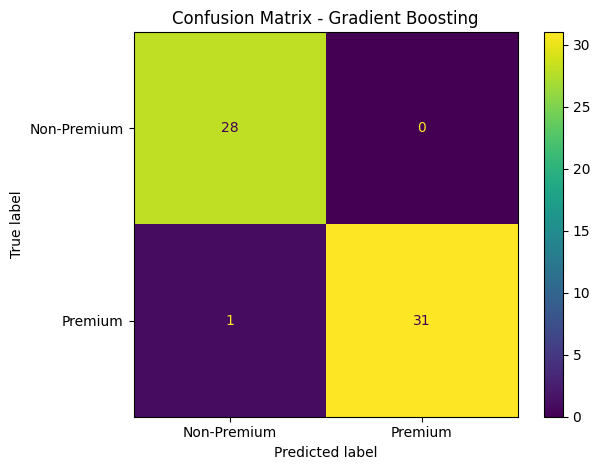

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_predict,
    display_labels=["Non-Premium","Premium"])
plt.title("Confusion Matrix - Gradient Boosting")
plt.tight_layout(); plt.show()

## 5. Feature Importance

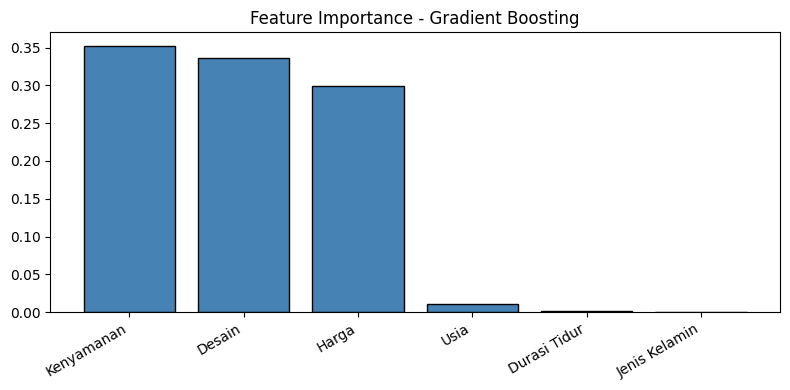

In [ ]:
import numpy as np
feature_names = ["Jenis Kelamin","Usia","Harga","Desain","Kenyamanan","Durasi Tidur"]
imp = clf.feature_importances_
idx = np.argsort(imp)[::-1]
plt.figure(figsize=(8,4))
plt.bar(range(len(feature_names)), imp[idx], color="steelblue", edgecolor="black")
plt.xticks(range(len(feature_names)), [feature_names[i] for i in idx], rotation=30, ha="right")
plt.title("Feature Importance - Gradient Boosting")
plt.tight_layout(); plt.show()

## 6. Uji Data Baru

In [ ]:
# [jk(0=L,1=P), usia, harga, desain, kenyamanan, durasi_tidur]
data_baru = [
    [0, 18, 2, 2, 2, 5],   # Skor rendah  (6) → Non-Premium
    [1, 22, 3, 3, 3, 6],   # Skor sedang  (9)
    [0, 25, 4, 4, 4, 7],   # Skor tinggi (12) → Premium
    [1, 27, 5, 5, 5, 8],   # Skor maks   (15) → Premium
    [0, 20, 1, 2, 2, 5],   # Skor minimal (5) → Non-Premium
]

predict_data = clf.predict(data_baru)
predict_proba = clf.predict_proba(data_baru)

print(f"Threshold yang digunakan: {threshold}")
print()
for i, (inp, pred, prob) in enumerate(zip(data_baru, predict_data, predict_proba)):
    skor = inp[2] + inp[3] + inp[4]
    status = "Menyukai Premium" if pred == 1 else "Tidak Menyukai Premium"
    print(f"  Data {i+1}: Skor={skor:2d} → {status} (keyakinan: {prob[pred]:.0%})")


Threshold yang digunakan: 9.0

  Data 1: Skor= 6 → Tidak Menyukai Premium (keyakinan: 100%)
  Data 2: Skor= 9 → Menyukai Premium (keyakinan: 88%)
  Data 3: Skor=12 → Menyukai Premium (keyakinan: 100%)
  Data 4: Skor=15 → Menyukai Premium (keyakinan: 100%)
  Data 5: Skor= 5 → Tidak Menyukai Premium (keyakinan: 100%)


c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


## 7. Simpan Model

In [ ]:
import pickle
with open('../flask-app/gb_model.pkl', 'wb') as f:
    pickle.dump({'model': clf, 'threshold': threshold}, f)
print("✅ gb_model.pkl tersimpan")

✅ gb_model.pkl tersimpan
